In [1]:
import numpy as np
import jax.numpy as jnp
from CartPole import *
from Rollout import *
from Model4Dim import *

/root/work/Rollout.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


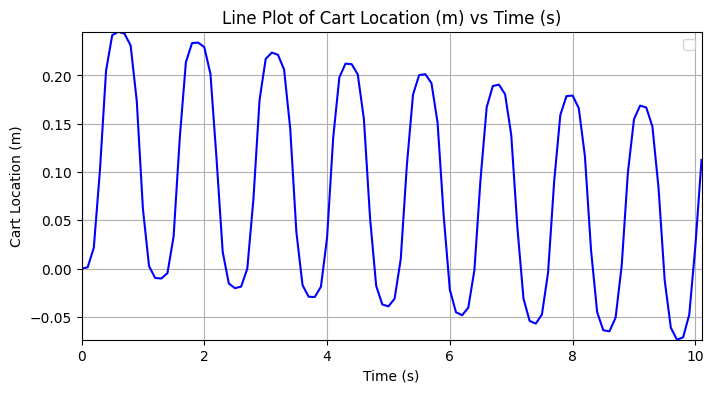

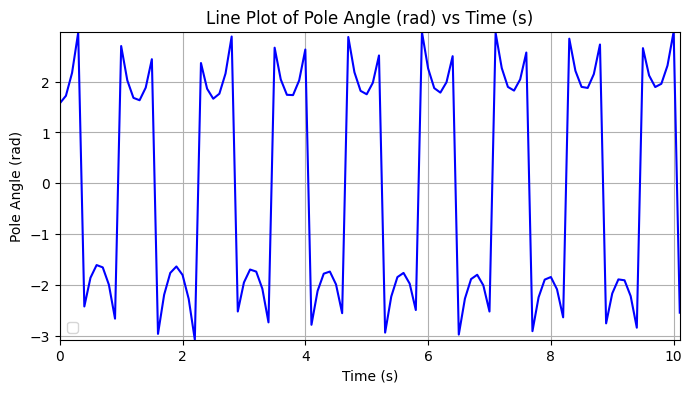

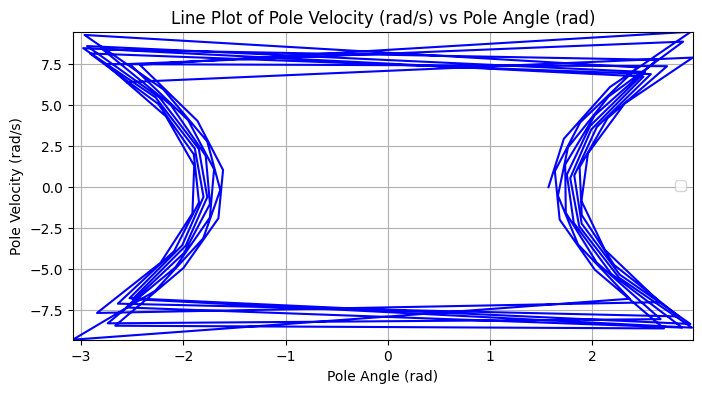

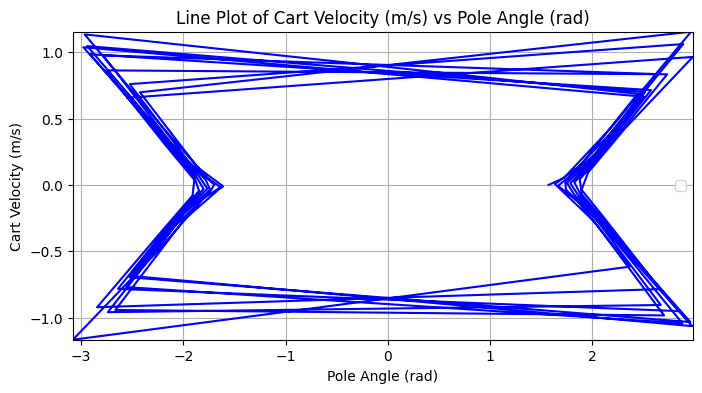

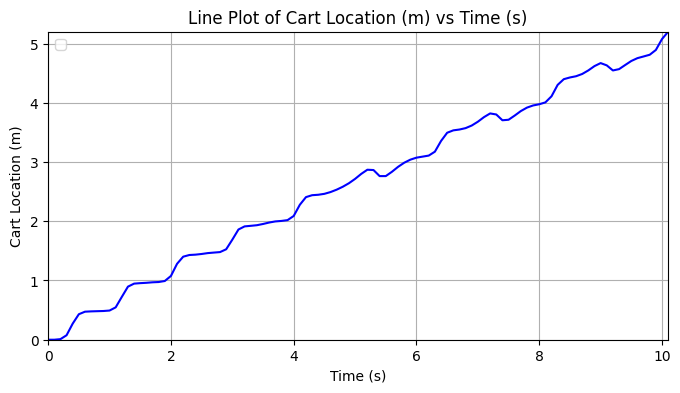

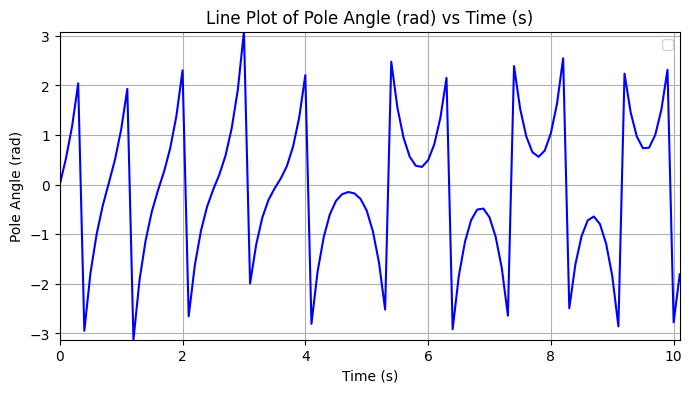

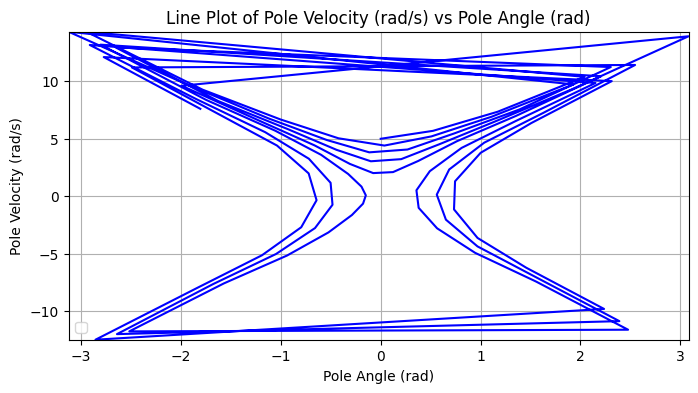

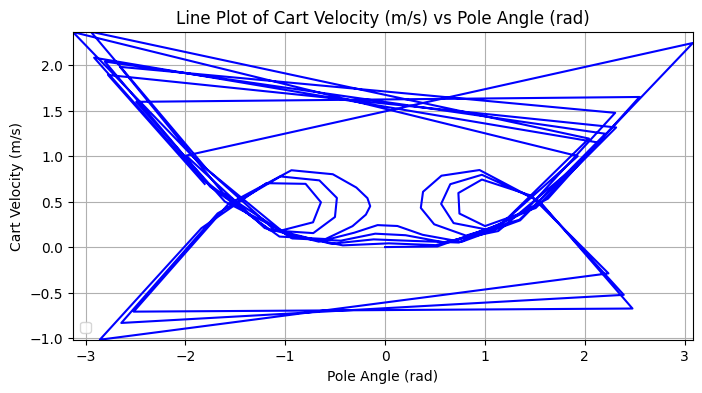

In [2]:
state_array, axis_names = rollout([0.0, 0.0, jnp.pi/2, 0.0], 10.0)
plotGraph(state_array, -1, 0, axis_names)
plotGraph(state_array, -1, 2, axis_names)
plotGraph(state_array, 2, 3, axis_names)
plotGraph(state_array, 2, 1, axis_names)

state_array, axis_names = rollout([0.0, 0.0, 0, 5.0], 10.0)
plotGraph(state_array, -1, 0, axis_names)
plotGraph(state_array, -1, 2, axis_names)
plotGraph(state_array, 2, 3, axis_names)
plotGraph(state_array, 2, 1, axis_names)

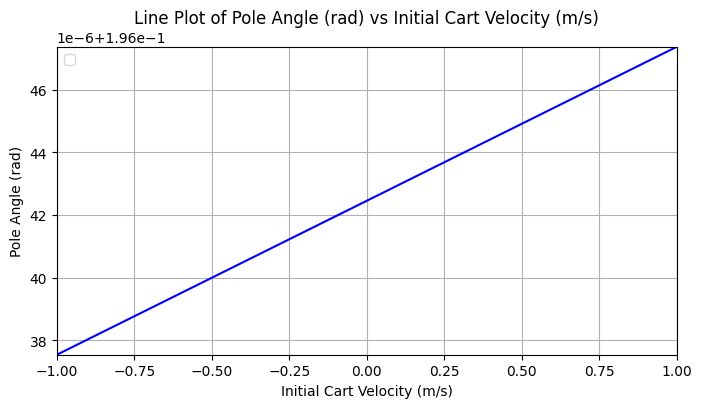

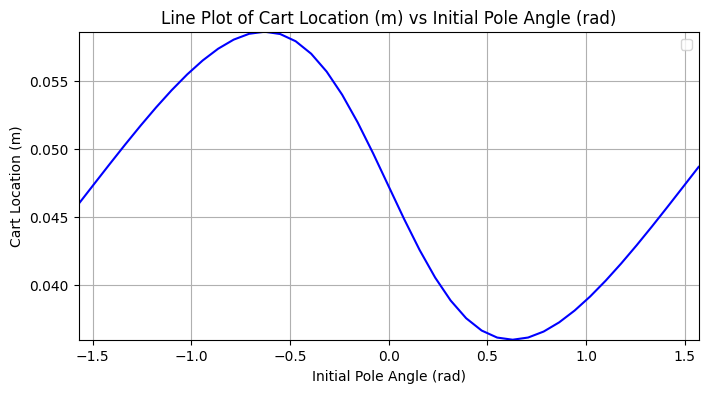

In [3]:
state_array, axis_names = oneDimLinearScan(1)
plotGraph(state_array, -1, 2, axis_names)

state_array, axis_names = oneDimLinearScan(2)
plotGraph(state_array, -1, 0, axis_names)

In [4]:
N = 4000
N_test = 1000
X_train, Y_train, _ = collect_data(N,[12,8,jnp.pi,5])
X_test, Y_test, axis_names = collect_data(N_test)

In [5]:
A_list = []
b_list = []

for j in range(Y_train.shape[1]):
    A_j, b_j = fit_linear(X_train, Y_train[:, j])
    A_list.append(A_j)
    b_list.append(b_j)

A = jnp.vstack(A_list)
b = jnp.array(b_list)

In [6]:
print(A)
print(b)

[[-6.8918821e-06  9.9961661e-02  3.9379089e-03  7.8984239e-04]
 [-5.3311946e-05 -4.7325014e-04  7.9514690e-02  2.2654755e-02]
 [-1.8178202e-05  2.1550352e-04  5.4204132e-02  9.9900886e-02]
 [-4.7945924e-04  4.7653276e-03  1.0508193e+00 -1.1192564e-03]]
[-7.4317722e-05 -2.1039592e-03  1.2756247e-03  2.6494019e-02]


In [7]:
linear_MSE = linear_MSE(X_test, Y_test, A, b)
print(linear_MSE)

[5.5303238e-03 1.8295053e+00 1.3212092e-02 5.6102147e+00]


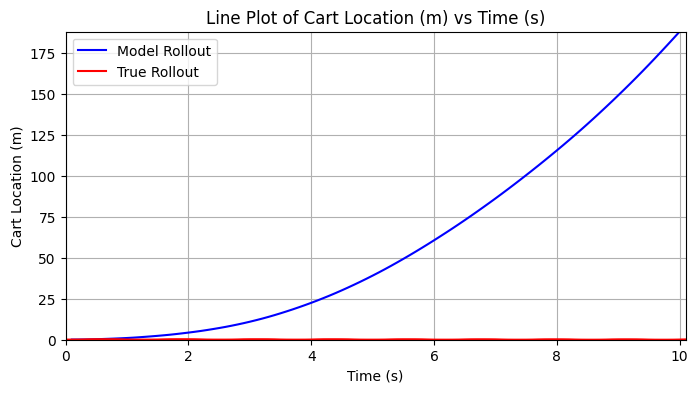

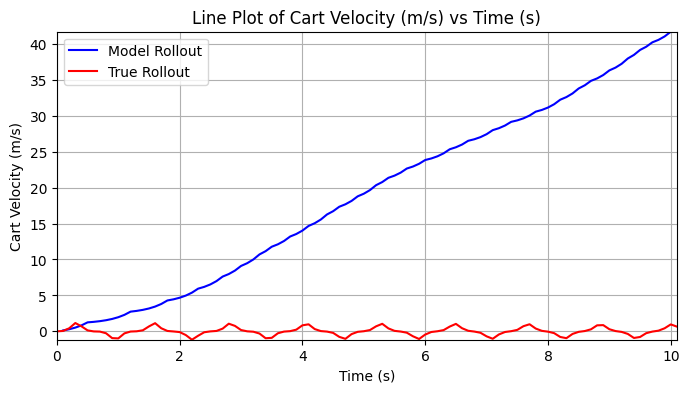

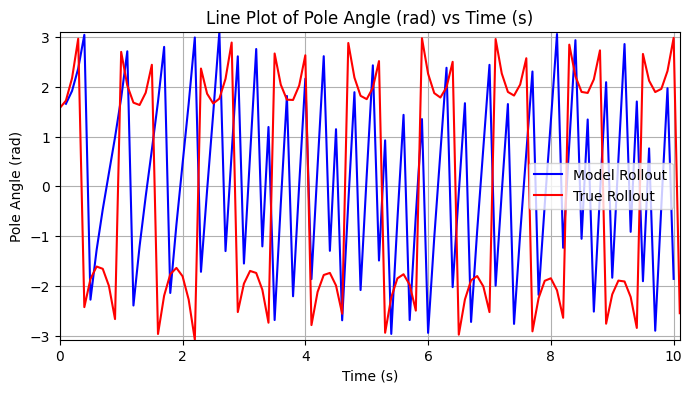

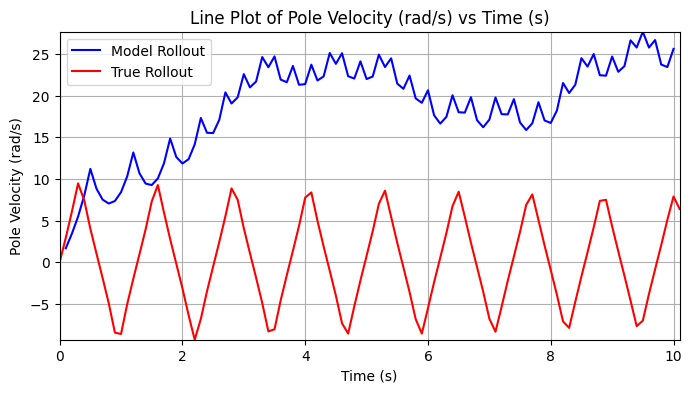

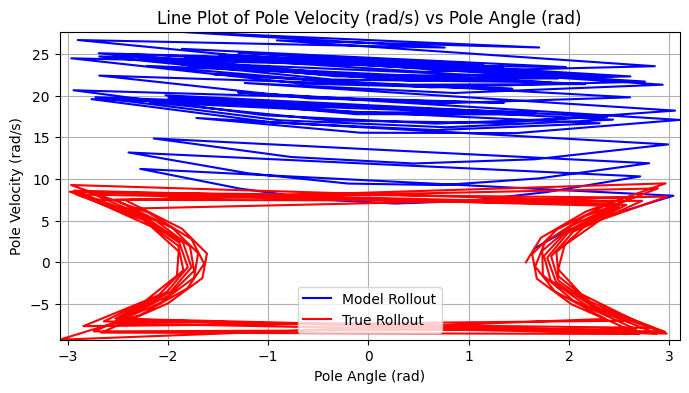

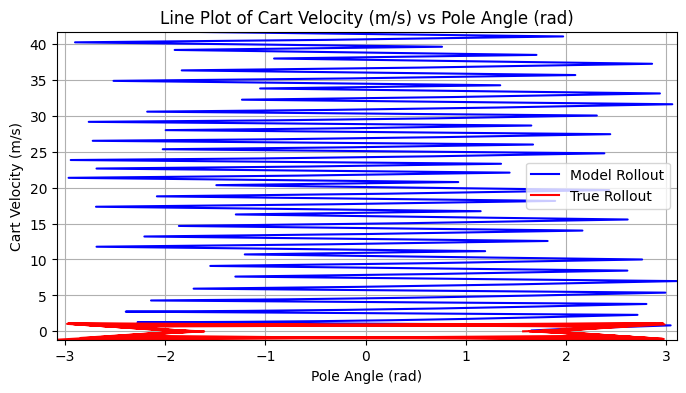

In [11]:
initial_state = jnp.array([0.0, 0.0, np.pi/2, 0.0])
state_array = linear_rollout(initial_state, A, b, 10)
true_state_array, axis_names = rollout(initial_state, 10)

plot_model_graph(state_array, true_state_array, -1, 0, axis_names)
plot_model_graph(state_array, true_state_array, -1, 1, axis_names)
plot_model_graph(state_array, true_state_array, -1, 2, axis_names)
plot_model_graph(state_array, true_state_array, -1, 3, axis_names)
plot_model_graph(state_array, true_state_array, 2, 3, axis_names)
plot_model_graph(state_array, true_state_array, 2, 1, axis_names)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=58725ef8-9a26-4e31-9e4c-5d3613b1a28f' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>